In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
import torch
from torch import nn

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [3]:
EPOCH = 100
LEARNING_RATE = .1
SEED=10203040
NOISE = 0.3
SAMPLES = 1000

In [4]:
def train(net, data, labels, loss_fn, epoch = 20, lr = .1):
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    losses = []
    for e in range(epoch):
        y_pred = net(data)
        loss = loss_fn(y_pred, labels)
        losses.append(loss.item())
        net.zero_grad()
        loss.backward()
        optimizer.step()
    return losses

In [5]:
X, y = make_moons(n_samples=SAMPLES, noise=NOISE, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=SEED)
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

In [6]:
loss_fn = nn.BCELoss()

In [7]:
model = nn.Sequential(
    nn.Linear(in_features=2, out_features=16),
    nn.LeakyReLU(),
    nn.Linear(in_features=16, out_features=16),
    nn.LeakyReLU(),
    nn.Linear(in_features=16, out_features=1),
    nn.Sigmoid(),
).to(device)

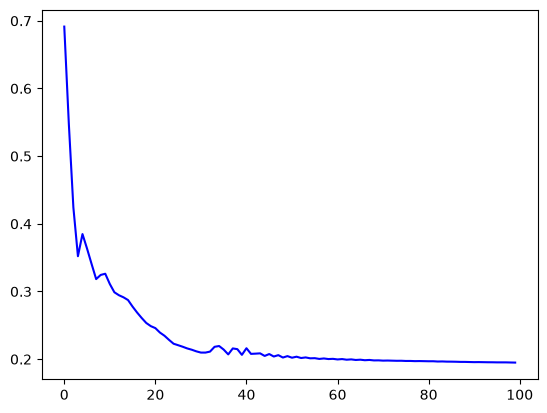

0.1949520707130432

In [8]:
loss = train(model, X_train, y_train, loss_fn, EPOCH, LEARNING_RATE)
plt.plot(loss, color="blue")
plt.show()
loss[-1]

In [9]:
model = model.to("mps")
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    test_loss = loss_fn(y_pred_test, y_test)
    predicted_labels = (y_pred_test > 0.5).float()
    accuracy = (predicted_labels == y_test).float().mean()

print(f"Test loss: {test_loss.item()}, Accuracy: {accuracy.item()}")

Test loss: 0.2330171912908554, Accuracy: 0.9121212363243103


/var/folders/n6/4mwsyk8d3sgcs0_g5vsnhzd00000gn/T/ipykernel_54074/2681744458.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


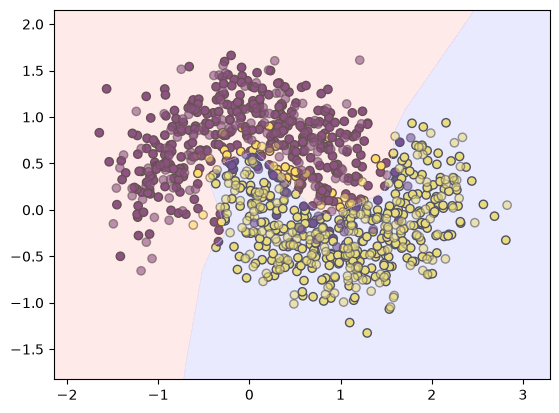

In [10]:

X_train = X_train.to("cpu")
y_train = y_train.to("cpu")
X_test = X_test.to("cpu")
y_test = y_test.to("cpu")
model = model.to("cpu")
ax = plt.subplot()
ax.scatter(
    X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="k"
)

ax.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    edgecolors="k",
    alpha=0.6,
)

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

model.eval()
with torch.no_grad():
    preds = model(grid).detach().cpu().numpy().reshape(xx.shape)

ax.contourf(xx, yy, preds, levels=[0, 0.5, 1], colors=["#ffcccc", "#ccccff"], alpha=0.4)

In [11]:
TEST_NOISE=0.05
X, y = make_moons(n_samples=SAMPLES, noise=TEST_NOISE, random_state=SEED + 123312)

X_next = torch.tensor(X, dtype=torch.float32)
y_next = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

model = model.to("cpu")
model.eval()
with torch.no_grad():
    y_pred_test = model(X_next)
    test_loss = loss_fn(y_pred_test, y_next)
    predicted_labels = (y_pred_test > 0.5).float()
    accuracy = (predicted_labels == y_next).float().mean()

print(f"Test loss: {test_loss.item()}, Accuracy: {accuracy.item()}")

Test loss: 0.04456906020641327, Accuracy: 0.9980000257492065


/var/folders/n6/4mwsyk8d3sgcs0_g5vsnhzd00000gn/T/ipykernel_54074/721711501.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


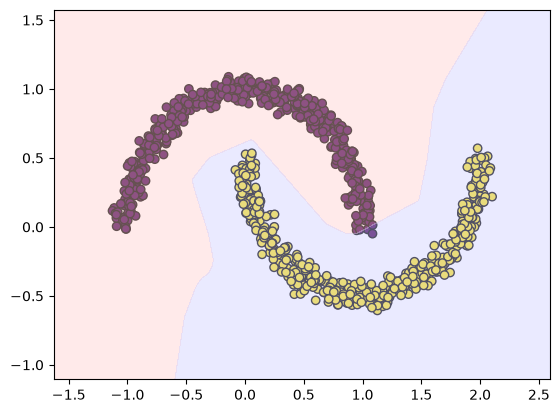

In [12]:
ax = plt.subplot()
ax.scatter(
    X_next[:, 0], X_next[:, 1], c=y_next, edgecolors="k"
)

x_min, x_max = X_next[:, 0].min() - 0.5, X_next[:, 0].max() + 0.5
y_min, y_max = X_next[:, 1].min() - 0.5, X_next[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

model.eval()
with torch.no_grad():
    preds = model(grid).detach().cpu().numpy().reshape(xx.shape)

ax.contourf(xx, yy, preds, levels=[0, 0.5, 1], colors=["#ffcccc", "#ccccff"], alpha=0.4)

Test loss: 2.389274835586548, Accuracy: 0.5040000081062317


/var/folders/n6/4mwsyk8d3sgcs0_g5vsnhzd00000gn/T/ipykernel_54074/1619735280.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


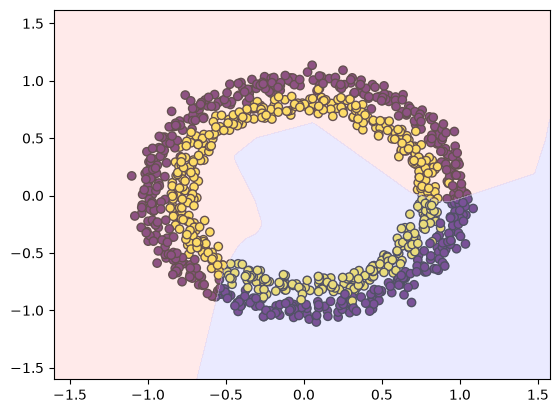

In [13]:
TEST_NOISE=0.05
X, y = make_circles(n_samples=SAMPLES, noise=TEST_NOISE, random_state=SEED + 212211)

X_next = torch.tensor(X, dtype=torch.float32)
y_next = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

model = model.to("cpu")
model.eval()
with torch.no_grad():
    y_pred_test = model(X_next)
    test_loss = loss_fn(y_pred_test, y_next)
    predicted_labels = (y_pred_test > 0.5).float()
    accuracy = (predicted_labels == y_next).float().mean()

print(f"Test loss: {test_loss.item()}, Accuracy: {accuracy.item()}")

ax = plt.subplot()
ax.scatter(
    X_next[:, 0], X_next[:, 1], c=y_next, edgecolors="k"
)

x_min, x_max = X_next[:, 0].min() - 0.5, X_next[:, 0].max() + 0.5
y_min, y_max = X_next[:, 1].min() - 0.5, X_next[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

model.eval()
with torch.no_grad():
    preds = model(grid).detach().cpu().numpy().reshape(xx.shape)

ax.contourf(xx, yy, preds, levels=[0, 0.5, 1], colors=["#ffcccc", "#ccccff"], alpha=0.4)

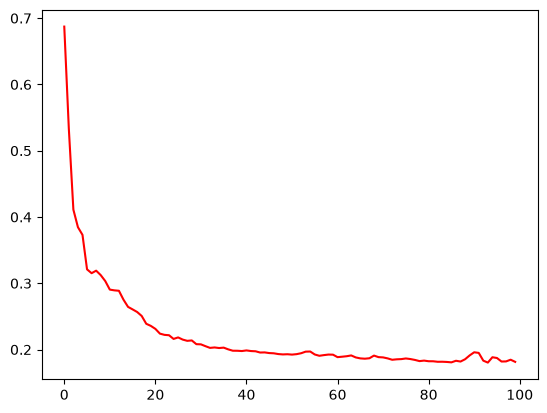

0.18143604695796967

In [14]:
model2 = nn.Sequential(
    nn.Linear(in_features=2, out_features=32),
    nn.LeakyReLU(),
    nn.Linear(in_features=32, out_features=32),
    nn.LeakyReLU(),
    nn.Linear(in_features=32, out_features=1),
    nn.Sigmoid(),
).to(device)

X_train = X_train.to("mps")
y_train = y_train.to("mps")

loss = train(model2, X_train, y_train, loss_fn, EPOCH, LEARNING_RATE)
plt.plot(loss, color="red")
plt.show()
loss[-1]

In [15]:
model2 = model2.to("mps")
X_test = X_test.to("mps")
y_test = y_test.to("mps")
model2.eval()
with torch.no_grad():
    y_pred_test = model2(X_test)
    test_loss = loss_fn(y_pred_test, y_test)
    predicted_labels = (y_pred_test > 0.5).float()
    accuracy = (predicted_labels == y_test).float().mean()

print(f"Test loss: {test_loss.item()}, Accuracy: {accuracy.item()}")

Test loss: 0.30023130774497986, Accuracy: 0.8999999761581421


In [16]:
X, y = make_moons(n_samples=SAMPLES, noise=TEST_NOISE, random_state=SEED + 123312)

X_next = torch.tensor(X, dtype=torch.float32)
y_next = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

model2 = model2.to("cpu")
model2.eval()
with torch.no_grad():
    y_pred_test = model2(X_next)
    test_loss = loss_fn(y_pred_test, y_next)
    predicted_labels = (y_pred_test > 0.5).float()
    accuracy = (predicted_labels == y_next).float().mean()

print(f"Test loss: {test_loss.item()}, Accuracy: {accuracy.item()}")

Test loss: 0.04561673104763031, Accuracy: 0.9929999709129333


/var/folders/n6/4mwsyk8d3sgcs0_g5vsnhzd00000gn/T/ipykernel_54074/1476055864.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


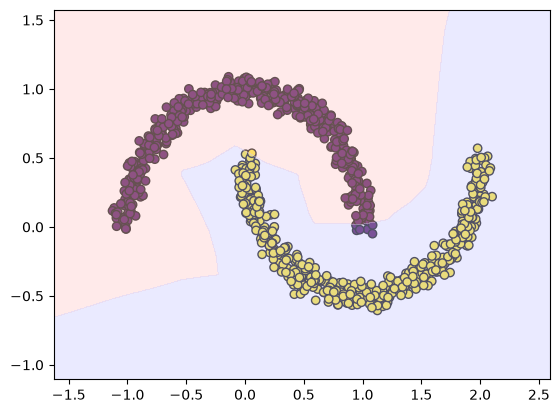

In [17]:
ax = plt.subplot()
ax.scatter(
    X_next[:, 0], X_next[:, 1], c=y_next, edgecolors="k"
)

x_min, x_max = X_next[:, 0].min() - 0.5, X_next[:, 0].max() + 0.5
y_min, y_max = X_next[:, 1].min() - 0.5, X_next[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

model2.eval()
with torch.no_grad():
    preds = model2(grid).detach().cpu().numpy().reshape(xx.shape)

ax.contourf(xx, yy, preds, levels=[0, 0.5, 1], colors=["#ffcccc", "#ccccff"], alpha=0.4)